In [516]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Acelerómetro con el celular sobre una mesa

#### a. Configure su experimento (celular + phyphox + entorno) para registrar valores de la componente vertical de la aceleración (az) del celular cuando deja el celular en reposo sobre una mesa, por ejemplo. Asegúrese de que su archivo contenga al menos 20000 datos medidos (típicamente, esto requiere registra datos por al menos un par de minutos)

Exportamos los datos obtenidos con la aplicación cuando el celular fue dejado sobre una superficie estable como lo es una mesa.

In [517]:
datos = np.genfromtxt("\\Users\\Catazla\\Desktop\\Universidad\\Lab I\\Tareas\\DatosT3.txt")

#### b.1. Visualice sus datos en un gráfico donde en el eje horizontal se muestre el número de la medición y en el vertical el valor del dato az registrado.

Text(0, 0.5, 'Aceleración de Gravedad $(m/s^2)$')

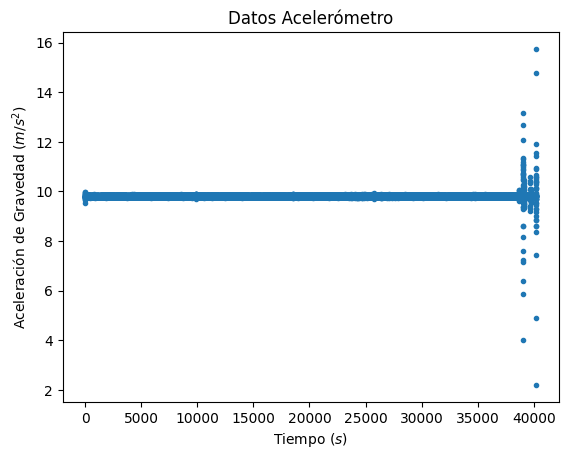

In [518]:
datos = np.array(datos).reshape(-1,1) 
g = datos[:,0]
x = np.arange(0,len(g))
plt.plot(x,g,".")
plt.title("Datos Acelerómetro")
plt.xlabel(r"Tiempo $(s)$")
plt.ylabel(r"Aceleración de Gravedad $(m/s^2)$")

#### b.2. “Limpie” sus datos. Es decir, elimine los datos que puedan ser atribuidos a movimientos impartidos por usted sobre el celular al tocarlo, al comienzo y al final del registro, y quédese sólo con aquellos donde el celular estuvo en reposo. Trabajará con estos datos en las actividades siguientes.

Text(0, 0.5, 'Aceleración de Gravedad $(m/s^2)$')

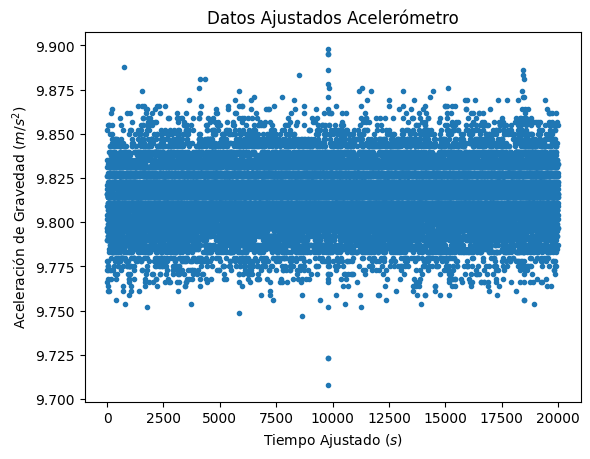

In [519]:
g_limpios = datos[50:20050,0]
x_limpios = np.arange(0,len(g_limpios))
plt.plot(x_limpios,g_limpios,".")
plt.title("Datos Ajustados Acelerómetro")
plt.xlabel(r"Tiempo Ajustado $(s)$")
plt.ylabel(r"Aceleración de Gravedad $(m/s^2)$")

#### c. Calcule el valor medio y la desviación estándar de sus datos.

In [520]:
mu = np.mean(g_limpios)
sigma = np.std(g_limpios)

#### d.1. Confeccione un histograma de sus datos, separándolos en 20 “bins”. 

Text(0, 0.5, 'Cantidad de Datos')

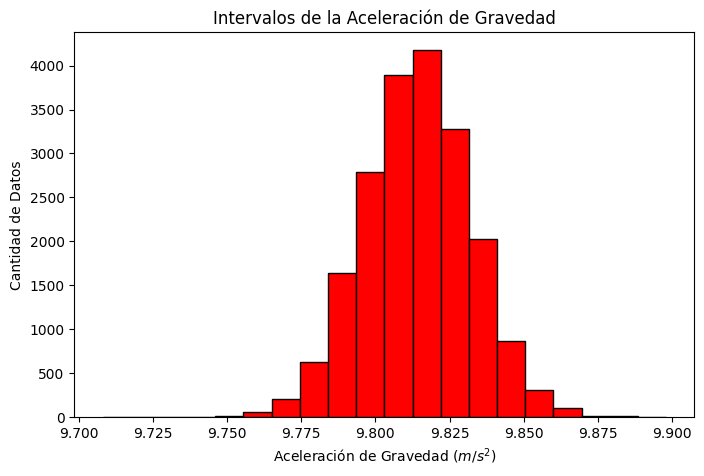

In [521]:
plt.figure(figsize=(8,5))
plt.hist(g_limpios, bins=20, color="red", edgecolor="black")
plt.title("Intervalos de la Aceleración de Gravedad")
plt.xlabel(r"Aceleración de Gravedad $(m/s^2)$")
plt.ylabel("Cantidad de Datos")

#### d.2. Comente las características que observa en el histograma. ¿Qué función cree que podría describir la tendencia general de histograma?

Observado el histograma podemos observar que la mayor concentración de datos está entre 9.800 y 9.825 aproximadamente, acercándose al valor conocido en la literatura de la gravedad. Por la forma en que se distribuyen los valores en el histograma se puede observar que tiene un comporamiento similar a una campana de Gauss.

#### e. Realice un ajuste de los datos del histograma (número de datos en el intervalo correspondiente a c/u de los 20 bins) con la función elegida en el punto anterior.

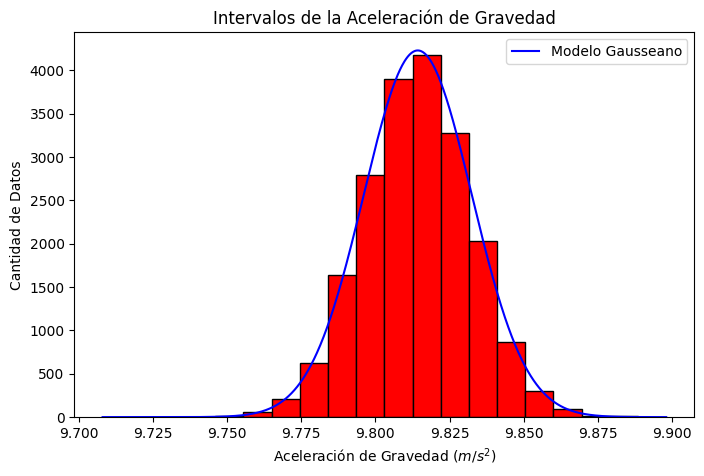

In [522]:
# Histograma en densidad
count, bins = np.histogram(g_limpios, bins=20)
centers = 0.5*(bins[1:] + bins[:-1])

# Gauss centrada (sin normalizar el pico aún)
gauss = np.exp(-((centers - mu)**2) / (2 * sigma**2))

scale = np.max(count) / np.max(gauss)

xx = np.linspace(np.min(g_limpios), np.max(g_limpios), 1000)
y = scale * np.exp(-((xx - mu)**2) / (2 * sigma**2))

plt.figure(figsize=(8,5))
plt.hist(g_limpios, bins=20, color="red", edgecolor="black")
plt.plot(xx, y, "blue", label="Modelo Gausseano")
plt.title("Intervalos de la Aceleración de Gravedad")
plt.xlabel(r"Aceleración de Gravedad $(m/s^2)$")
plt.ylabel("Cantidad de Datos")
plt.legend()
plt.show()

#### f. Realice un análisis de los residuos de su ajuste.

Text(0, 0.5, 'Residuos')

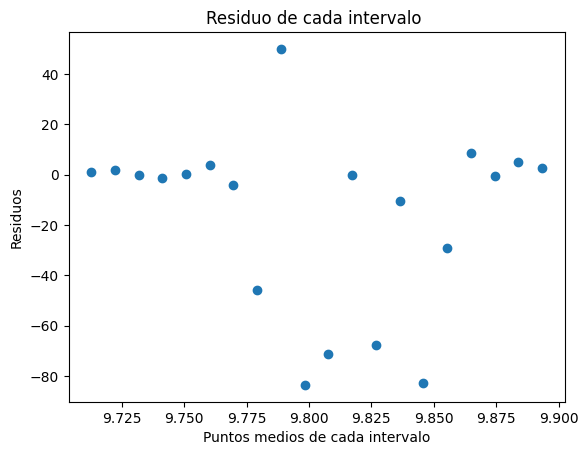

In [523]:
bin_centers = 0.5 * (bins[1:] + bins[:-1])
gauss_model_scaled = scale * gauss
res = count - gauss_model_scaled
plt.scatter(bin_centers, res)
plt.title("Residuo de cada intervalo ")
plt.xlabel("Puntos medios de cada intervalo")
plt.ylabel("Residuos")

Al observar los residuos podemos observar que, para el centro del histograma, se comporta de manera aleatoria, por lo que no tenemos errores sistemáticos. Ahora bien ¿Por qué en los extremos el residuo es 0? Pues, como los datos que obtuvieron más bajos o altos fueron muy despreciables a comparación de la mayoría de los datos que se concentraron entre 9.750 y 9.875 aproximadamente, es por ello que visualmente pareciera el modelo que elegimos toca el eje para aquellos intervalos, y debido a esto también es que en los residuos, para los casos extremos del histograma, se centran en 0.

# Acelerómetro con el celular sobre la mano

#### a. Configure su experimento (celular + phyphox + entorno) para registrar valores de la componente vertical de la aceleración (az) del celular cuando deja el celular en reposo sobre una mesa, por ejemplo. Asegúrese de que su archivo contenga al menos 20000 datos medidos (típicamente, esto requiere registra datos por al menos un par de minutos)

Exportamos los datos obtenidos con la aplicación cuando el celular fue dejado sobre una superficie inestable como lo es la palma de la mano.

In [524]:
datus = np.genfromtxt("\\Users\\Catazla\\Desktop\\Universidad\\Lab I\\Tareas\\DatosT3_2.txt")

#### b.1. Visualice sus datos en un gráfico donde en el eje horizontal se muestre el número de la medición y en el vertical el valor del dato az registrado.

Text(0, 0.5, 'Aceleración de Gravedad (m/s**2)')

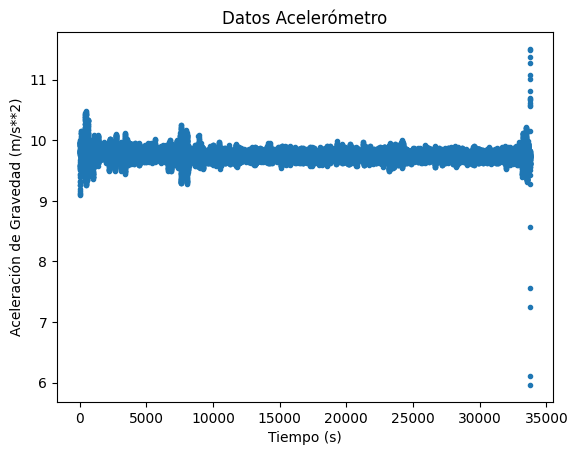

In [525]:
datus = np.array(datus).reshape(-1,1) 
g = datus[:,0]
x = np.arange(0,len(g))
plt.plot(x,g,".")
plt.title("Datos Acelerómetro")
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleración de Gravedad (m/s**2)")

#### b.2. “Limpie” sus datos. Es decir, elimine los datos que puedan ser atribuidos a movimientos impartidos por usted sobre el celular al tocarlo, al comienzo y al final del registro, y quédese sólo con aquellos donde el celular estuvo en reposo. Trabajará con estos datos en las actividades siguientes.

Text(0, 0.5, 'Aceleración de Gravedad $(m/s^2)$')

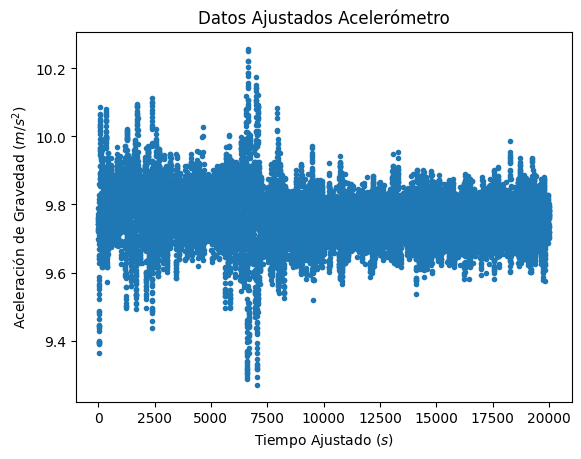

In [526]:
gm_limpios = datus[1000:21000,0]
xm_limpios = np.arange(0,len(gm_limpios))
plt.plot(xm_limpios,gm_limpios,".")
plt.title("Datos Ajustados Acelerómetro")
plt.xlabel(r"Tiempo Ajustado $(s)$")
plt.ylabel(r"Aceleración de Gravedad $(m/s^2)$")

#### c. Calcule el valor medio y la desviación estándar de sus datos.

In [527]:
mum = np.mean(gm_limpios)
sigmam = np.std(gm_limpios)

#### d.1. Confeccione un histograma de sus datos, separándolos en 20 “bins”. 

C:\Users\Catazla\AppData\Local\Temp\ipykernel_18524\253469745.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


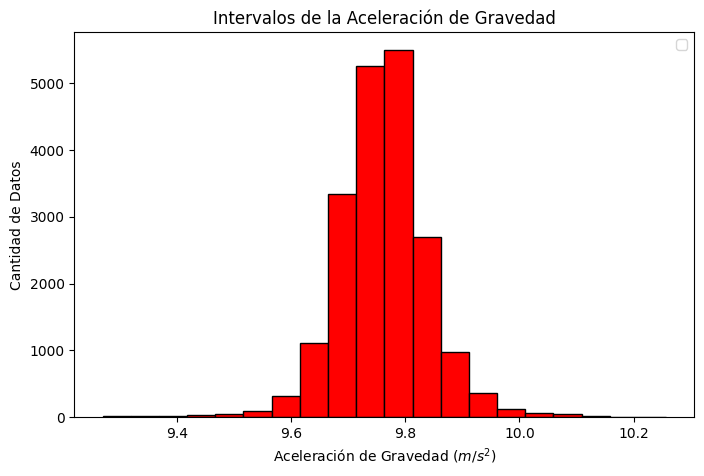

In [528]:
plt.figure(figsize=(8,5))
plt.hist(gm_limpios, bins=20, color="red", edgecolor="black")
plt.title("Intervalos de la Aceleración de Gravedad")
plt.xlabel(r"Aceleración de Gravedad $(m/s^2)$")
plt.ylabel("Cantidad de Datos")
plt.legend()
plt.show()

#### d.2. Comente las características que observa en el histograma. ¿Qué función cree que podría describir la tendencia general de histograma?

Observado el histograma podemos observar que la mayor concentración de datos está entre 9.6 y 10 aproximadamente, en este caso hay una diferencia decimal con respecto al valor conocido en la literatura de la gravedad. Al igual que el caso anterior, por la forma en que se distribuyen los valores en el histograma se puede observar que tiene un comporamiento similar a una campana de Gauss.

#### e. Realice un ajuste de los datos del histograma (número de datos en el intervalo correspondiente a c/u de los 20 bins) con la función elegida en el punto anterior.

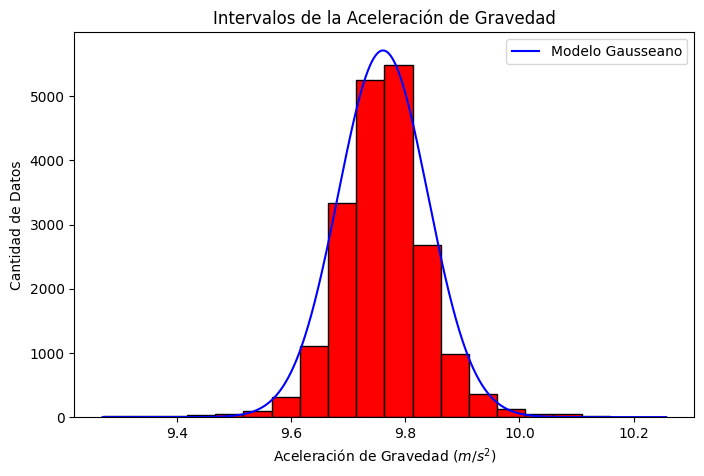

In [529]:
# Histograma en densidad
count, bins = np.histogram(gm_limpios, bins=20)
centers = 0.5*(bins[1:] + bins[:-1])

# Gauss centrada (sin normalizar el pico aún)
gauss = np.exp(-((centers - mum)**2) / (2 * sigmam**2))

scale = np.max(count) / np.max(gauss)

xx = np.linspace(np.min(gm_limpios), np.max(gm_limpios), 1000)
y = scale * np.exp(-((xx - mum)**2) / (2 * sigmam**2))

plt.figure(figsize=(8,5))
plt.hist(gm_limpios, bins=20, color="red", edgecolor="black")
plt.plot(xx, y, "blue", label="Modelo Gausseano")
plt.title("Intervalos de la Aceleración de Gravedad")
plt.xlabel(r"Aceleración de Gravedad $(m/s^2)$")
plt.ylabel("Cantidad de Datos")
plt.legend()
plt.show()

#### f. Realice un análisis de los residuos de su ajuste.

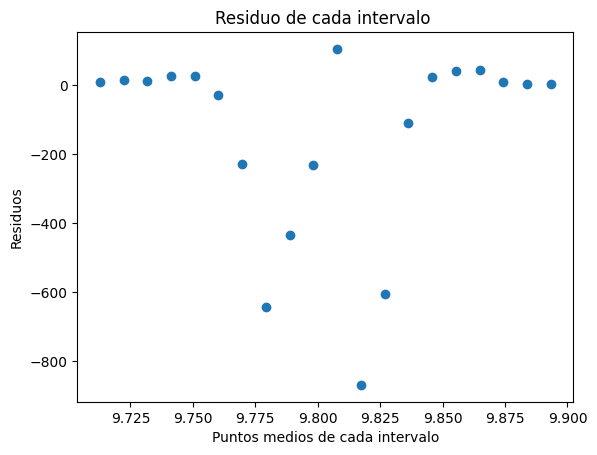

In [530]:
gauss_model_scaled = scale * gauss
res = count - gauss_model_scaled
plt.scatter(bin_centers, res)
plt.title("Residuo de cada intervalo ")
plt.xlabel("Puntos medios de cada intervalo")
plt.ylabel("Residuos")
plt.show()


Al observar los residuos podemos notar que se comporta de manera similar que en el otro gráfico, con dispersión en el centro y concentración en 0 en los extremos. La explicación a este fenómeno no varía con respecto al caso anterior, los datos que obtuvieron valores más bajos o altos fueron muy despreciables a comparación de la mayoría de los datos que se concentraron entre 9.6 y 10 aproximadamente en este experimento, es por ello que visualmente pareciera el modelo que elegimos toca el eje para aquellos intervalos, y debido a esto también es que en los residuos, para los casos extremos del histograma, se centran en 0.

#### h. Compare, discuta e intente explicar las caracteristicas observadas en sus datos

Haciendo la comparación entre los datos obtenidos con el celular sobre la mesa y sobre la palma de la mano podemos observar que los datos que tienen mayor precisión respecto al valor de la gravedad que señala la literatura es el caso de la mesa, en cambio en el caso de la mano varía un par de decimas al resultado esperado.

Las razones por las cuales esto sucede es sencillamente por la estabilidad que ofrece cada superficie. La mesa, al ser un objeto firme e inmovil (a no ser que se le aplique una fuerza suficiente para moverla, pero en este caso no sucede) no genera un desequilibrio en la toma de datos. En cambio para las mediciones usando la mano como soporte pueden variar del mismo modo que una mano varia su movimiento estando extendida con un peso. Hay factores como la respiración, el pulso, la resistencia y reacciones corporales que influyen directamente a que tan estable puede estar el celular ahí. 